In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, MinMaxScaler
import numpy as np
import tensorflow as tf 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


def load_csv(filePath, sep=','):
    return pd.read_csv(filePath, sep=sep)

def engineer_features(df):
    df = df.copy()
    # Age in years
    df['age_years'] = df['age'] // 365
    # BMI
    df['bmi'] = df['weight'] / ((df['height'] / 100) ** 2)
    # Pulse pressure
    df['pulse_pressure'] = df['bp_high'] - df['bp_low']
    # Hypertension flag
    df['is_hypertensive'] = ((df['bp_high'] >= 140) | (df['bp_low'] >= 90)).astype(int)
    # Combined metabolic risk
    df['risk_level'] = df['cholesterol'] + df['glucose_level']
    # Drop raw columns used to create features
    df.drop(columns=[
        'age', 'height', 'weight', 'bp_high', 'bp_low', 'cholesterol', 'glucose_level'
    ], inplace=True)
    return df

def split_features_target(df, yColumn, dropColumns):
    X = df.drop(columns=dropColumns + [yColumn])
    y = df[yColumn]
    return X, y

def apply_polynomial(X, degree=2):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly.fit_transform(X)
    columns = poly.get_feature_names_out(X.columns if isinstance(X, pd.DataFrame) else None)
    return pd.DataFrame(X_poly, columns=columns)

def apply_scaling(X, exclude=[]):
    scaler = MinMaxScaler()

    # Separate excluded columns
    X_excluded = X[exclude]
    
    # Drop excluded columns and scale the rest
    X_dropped = X.drop(columns=exclude)
    X_scaled = scaler.fit_transform(X_dropped)
    
    # Create DataFrame from scaled data
    X_scaled_df = pd.DataFrame(X_scaled, columns=X_dropped.columns, index=X.index)
    
    # Concatenate scaled and excluded columns
    X_combined = pd.concat([X_scaled_df, X_excluded], axis=1)

    # Optional: preserve original column order
    X_combined = X_combined[X.columns]

    return X_combined

def split_data(X, y, test_size=0.4, cv_size=0.5, seed=42):
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=test_size, random_state=seed)
    X_cv, X_test, y_cv, y_test = train_test_split(X_temp, y_temp, test_size=cv_size, random_state=seed)
    return X_train, y_train, X_cv, y_cv, X_test, y_test

def apply_encoding(columns, df):
    df = pd.get_dummies(df, columns=columns, drop_first=False)
    return df

def prepare_data(filePath, 
                 yColumn, 
                 csv_sep=',',
                 scale=True,
                 polynomial=False,
                 polyDegree=2,
                 dropColumns=[],
                 exclude_scaling=[],
                 encoding_columns=[]):

    df = load_csv(filePath, sep=csv_sep)

    # Apply feature engineering
    # df = engineer_features(df)

    if(len(encoding_columns)>0):        
        df = apply_encoding(encoding_columns, df)

    # Drop duplicate drops (prevent appending yColumn every call)
    dropCols = list(dropColumns)  # copy list to avoid side effects
    if yColumn not in dropCols:
        dropCols.append(yColumn)

    X, y = split_features_target(df, yColumn, dropCols)

    if polynomial:
        X = apply_polynomial(X, degree=polyDegree)

    if scale:
        X = apply_scaling(X,exclude_scaling)

    return split_data(X, y)


def train_model(X, y, w=None, epochs = 100):
    model = LogisticRegressionCV(max_iter=epochs,
                             solver='lbfgs', 
                             penalty='l2',
                            #  Cs=[0.001, 0.01, 0.1, 1, 10],
                             random_state=52,
                             n_jobs=2, 
                             class_weight='balanced')
    model.fit(X,y, w)

    print('Max Iterations:', epochs)
    print('Training Score: ',model.score(X, y))
    print('Training Cs: ',model.Cs_)
    print('Total Iterations',model.n_iter_)    
    

    return model


def predict_plot(model, X, y, plottingSample = None, predictionLine=True, dotsWithPridction=False):
    y_hats = model.predict(X)

    print('Training Score: ',model.score(X, y))
    print('Training Cs: ',model.Cs_)
    
    if(plottingSample == None):
        plottingSample = len(y_hats)

    plt.scatter(range(plottingSample), y[:plottingSample], label='True Y')
    if dotsWithPridction:
        plt.scatter(range(plottingSample), y_hats[:plottingSample],color='red' )
    if predictionLine:
        plt.plot(range(plottingSample), y_hats[:plottingSample], label='Predicted Y (Line)', color='green')
        
    plt.title('Prediction vs True Values')
    plt.xlabel('Index')
    plt.ylabel('Y Value')
    # plt.legend()
    plt.show()

def combine_datasets(X1, y1, X2, y2):
     X = np.concatenate((X1, X2), axis=0)
     y = np.concatenate((y1, y2), axis=0)
     
     return X,y


In [7]:
dsPath = '../data/NuralNetwork/house_pricing_linear_10m_TN_0_FN_0.csv'
yColumn  = 'SalePrice'
encoding_columns = ['ExteriorQuality','FloorMaterial','SaleSeason']

X_train, y_train, X_cv, y_cv, X_test, y_test = prepare_data(dsPath,
                                                            yColumn,
                                                            dropColumns=[],
                                                            polynomial=True,
                                                            polyDegree=1,
                                                            exclude_scaling=['HasPool', 'HasFireplace'],
                                                            encoding_columns=encoding_columns
                                                             )

# y_train = apply_scaling(pd.DataFrame(y_train,columns=[yColumn]))[yColumn]
# y_test = apply_scaling(pd.DataFrame(y_test,columns=[yColumn]))[yColumn]
# y_cv = apply_scaling(pd.DataFrame(y_cv,columns=[yColumn]))[yColumn]


X = X_train
y = y_train
no_of_features = X.shape[1]

# X, y = combine_datasets(X, y, X_test, y_test)
X, y = combine_datasets(X, y, X_cv, y_cv)
# input_dim = int(X_train.shape[1])  # make sure it's an int

# print(X_train.columns)
print(X_train.shape)
print(y_train.shape)

print(X_cv.shape)
print(y_cv.shape)

print(X_test.shape)
print(y_test.shape)
# ExteriorQuality
# ExteriorQuality


(6000000, 30)
(6000000,)
(2000000, 30)
(2000000,)
(2000000, 30)
(2000000,)


In [24]:
batch_size=1024

model = Sequential([
    Dense(no_of_features * 2, activation='linear', input_shape=( int(X.shape[1]),)),
    Dense(no_of_features * 2, activation='relu'),
    Dense(no_of_features, activation='relu'),
    Dense(no_of_features, activation='relu'),
    Dense(no_of_features // 2, activation='relu'), 
    Dense(no_of_features // 2, activation='relu'), 
    Dense(no_of_features // 4, activation='relu'), 
    Dense(no_of_features // 4, activation='relu'), 
    Dense(1, activation='relu')
])

model.compile(optimizer=Adam(learning_rate=0.00001),
              loss='mse',
              metrics=['mae'])


early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Step 7: Train the model
history = model.fit(X, y,
                    epochs=1000,
                    batch_size=batch_size,
                    validation_split=0.2,
                    callbacks=[early_stop])

Epoch 1/1000
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 45s 6ms/step - loss: 201769762816.0000 - mae: 437152.3438 - val_loss: 200676327424.0000 - val_mae: 435915.4062
Epoch 2/1000
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 36s 6ms/step - loss: 197244026880.0000 - mae: 431960.7500 - val_loss: 167592476672.0000 - val_mae: 396512.6562
Epoch 3/1000
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 38s 6ms/step - loss: 137252724736.0000 - mae: 353190.6250 - val_loss: 24244277248.0000 - val_mae: 131408.6250
Epoch 4/1000
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 38s 6ms/step - loss: 13717199872.0000 - mae: 94188.8984 - val_loss: 8574949376.0000 - val_mae: 74672.1250
Epoch 5/1000
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 38s 6ms/step - loss: 8263863296.0000 - mae: 73322.8594 - val_loss: 7263404544.0000 - val_mae: 68712.0859
Epoch 6/1000
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 39s 6ms/step - loss: 6891740160.0000 - mae: 66909.8125 - val_loss: 5724044288.0000 - val_mae: 60947.8711
Epoch 7/1000
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 42s 6ms/step - loss: 5289581056.0000 - mae: 

In [25]:
X_test = np.array(X_test)
y_test = np.array(y_test)

# Step 8: Evaluate
print(model.metrics_names)
loss, mae = model.evaluate(X_test, y_test,batch_size=batch_size)
print(f"\n✅ Test MAE (Mean Absolute Error): {mae}")
print(f"✅ Test Loss: {loss}")

['loss', 'compile_metrics']
1954/1954 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 2.6339 - mae: 0.2071

✅ Test MAE (Mean Absolute Error): 0.20828218758106232
✅ Test Loss: 2.647016763687134


652/652 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


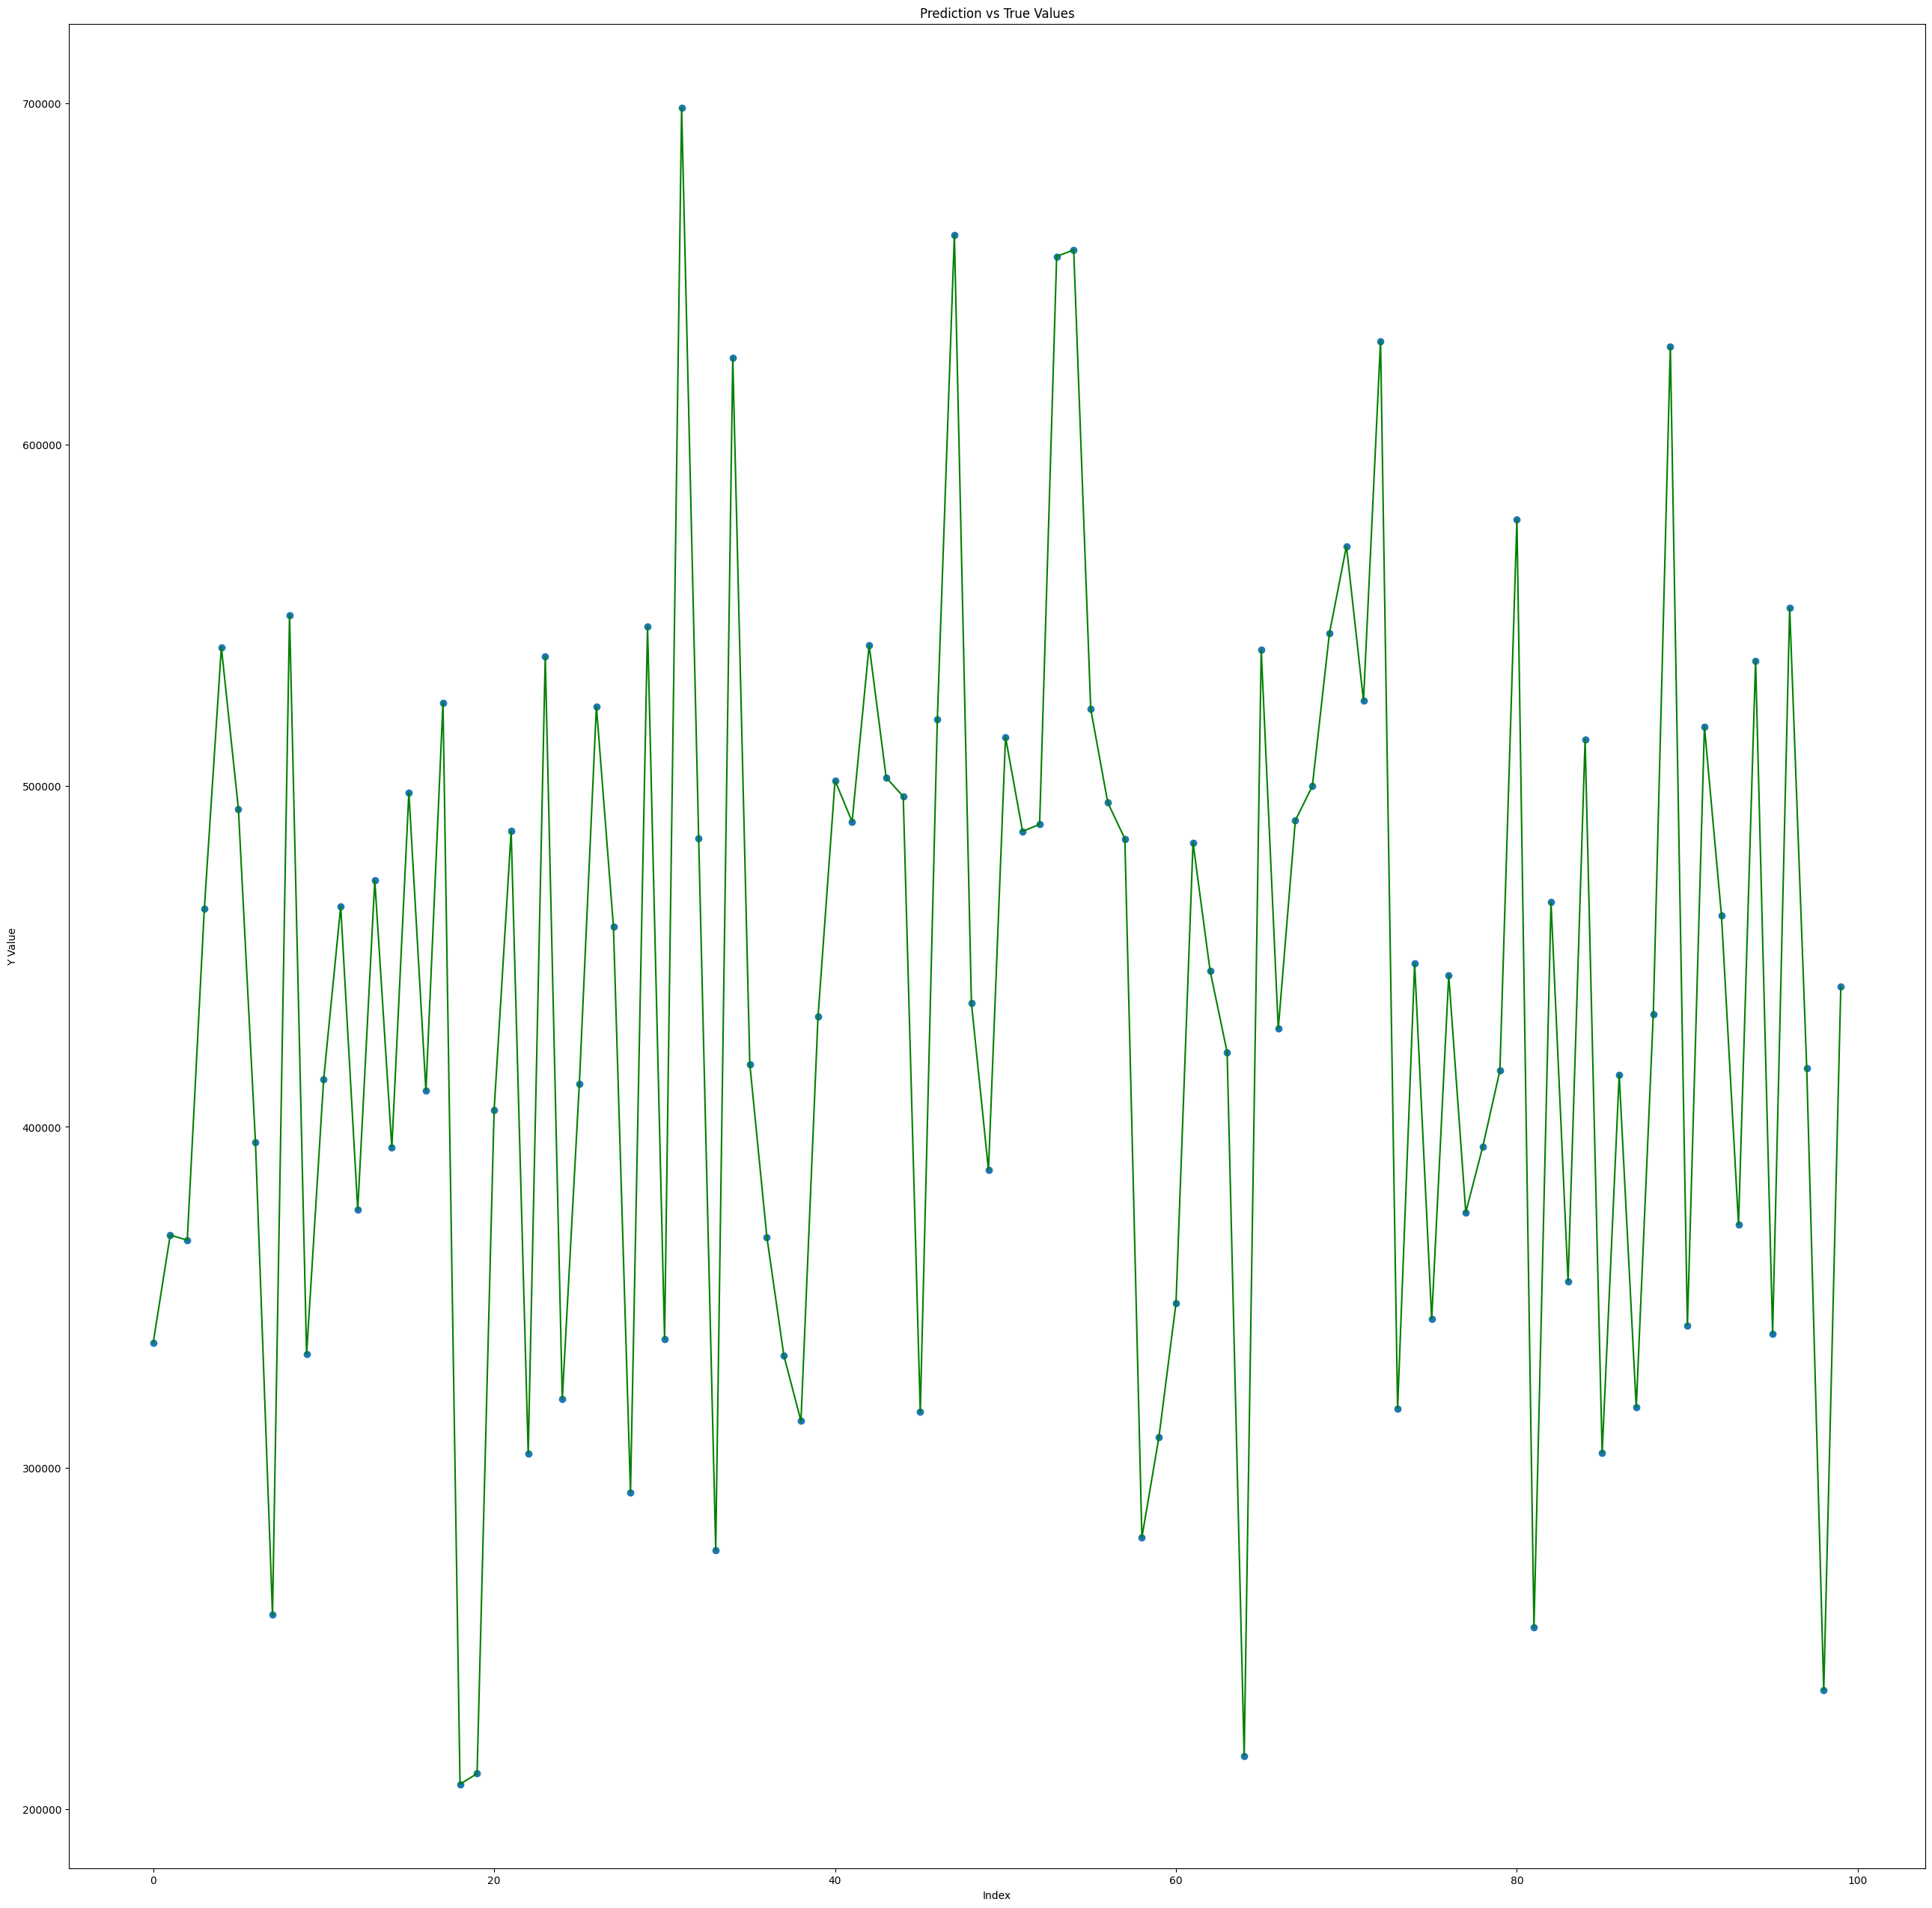

In [35]:

# Step 9: Predict
y_hats = model.predict(X_test,batch_size=batch_size*3)


plottingSample = 100
plt.figure(figsize=(32, 32)) 
plt.scatter(range(plottingSample), y_test[:plottingSample], label='True Y')
# plt.scatter(range(plottingSample), y_hats[:plottingSample],color='red' )
plt.plot(range(plottingSample), y_hats[:plottingSample], label='Predicted Y (Line)', color='green')
    
plt.title('Prediction vs True Values')
plt.xlabel('Index')
plt.ylabel('Y Value')
# plt.legend()
plt.show()